# makemore: becoming a backprop ninja

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X, device=device)
  Y = torch.tensor(Y, device=device)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
# compare a manual gradient with the PyTorch gradient
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [6]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g).to(device)
# Layer 1
W1 = (torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)).to(device)
b1 = (torch.randn(n_hidden,                        generator=g) * 0.1).to(device)
# Layer 2
W2 = (torch.randn((n_hidden, vocab_size),          generator=g) * 0.1).to(device)
b2 = (torch.randn(vocab_size,                      generator=g) * 0.1).to(device)
# BatchNorm parameters
bngain = (torch.randn((1, n_hidden))*0.1 + 1.0).to(device)
bnbias = (torch.randn((1, n_hidden))*0.1).to(device)

# Small random values help expose incorrect gradients.
parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

4137


In [7]:
batch_size = 32
n = batch_size # a shorter variable for convenience

# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g).to(device)
Xb, Yb = Xtr[ix], Ytr[ix]

In [8]:
# forward pass, split into small steps we can backpropagate one at a time
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)

# Linear layer 1
hprebn = embcat @ W1 + b1

# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # Bessel's correction
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias

# Non-linearity
h = torch.tanh(hpreact)

# Linear layer 2
logits = h @ W2 + b2

# cross entropy loss, written out one operation at a time
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass for checking our work
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
          bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
          embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3373, device='cuda:0', grad_fn=<NegBackward0>)

## exercise 1: backpropagate every operation

Walk backward through the exact tensors created above and compare every result with PyTorch.

In [9]:
logprobs.shape, Yb.shape, logprobs[range(n), Yb].shape

(torch.Size([32, 27]), torch.Size([32]), torch.Size([32]))

In [ ]:
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n # others remain grad = 0
cmp('logprobs', dlogprobs, logprobs)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0


In [11]:
dprobs = (1.0 / probs) * dlogprobs
cmp('probs', dprobs, probs)

probs           | exact: True  | approximate: True  | maxdiff: 0.0


In [ ]:
# counts_sum_inv was broadcast across every row.
counts.shape, counts_sum_inv.shape
# a[3x3] * b[3x1] broadcasting ---->
# a11*b1 a12*b1 a13*b1
# a21*b2 a22*b2 a23*b2
# a31*b3 a32*b3 a33*b3
# ->
# c[3x3] = a[3x3] * b[3x1] elementwise broadcasting

(torch.Size([32, 27]), torch.Size([32, 1]))

In [13]:
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)

counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0


In [14]:
# This is only the first path into counts.
dcounts = counts_sum_inv * dprobs
dcounts.shape

torch.Size([32, 27])

In [15]:
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
cmp('counts_sum', dcounts_sum, counts_sum)

counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0


In [16]:
counts.shape, counts_sum.shape

(torch.Size([32, 27]), torch.Size([32, 1]))

In [17]:
# A sum in the forward pass becomes a broadcast in the backward pass.
dcounts += torch.ones_like(counts) * dcounts_sum
cmp('counts', dcounts, counts)

counts          | exact: True  | approximate: True  | maxdiff: 0.0


In [18]:
dnorm_logits = counts * dcounts
cmp('norm_logits', dnorm_logits, norm_logits)

norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0


In [19]:
norm_logits.shape, logits.shape, logit_maxes.shape

(torch.Size([32, 27]), torch.Size([32, 27]), torch.Size([32, 1]))

In [20]:
# The subtraction sends one path to each input.
dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
cmp('logit_maxes', dlogit_maxes, logit_maxes)

logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0


In [ ]:
# This should be almost zero because subtracting a row constant does not change softmax.
dlogit_maxes
# max of logits just used for numerical stability in softmax, do not affect the output of softmax, so the gradient with respect to this max should be almost zero.

tensor([[ 1.8626e-09],
        [ 0.0000e+00],
        [ 9.3132e-10],
        [ 6.5193e-09],
        [-5.5879e-09],
        [ 0.0000e+00],
        [-1.8626e-09],
        [-1.8626e-09],
        [ 9.3132e-10],
        [ 0.0000e+00],
        [ 1.8626e-09],
        [ 0.0000e+00],
        [ 4.6566e-09],
        [-1.8626e-09],
        [ 3.7253e-09],
        [ 5.5879e-09],
        [ 3.7253e-09],
        [ 0.0000e+00],
        [ 3.7253e-09],
        [-3.7253e-09],
        [ 1.8626e-09],
        [-1.8626e-09],
        [ 3.7253e-09],
        [ 3.7253e-09],
        [-9.3132e-10],
        [-9.3132e-10],
        [ 3.7253e-09],
        [ 1.8626e-09],
        [ 0.0000e+00],
        [-1.8626e-09],
        [ 0.0000e+00],
        [-1.8626e-09]], device='cuda:0', grad_fn=<SumBackward1>)

In [22]:
logits.max(1).indices

tensor([ 1,  2, 19, 15, 15, 25, 16,  3,  7,  8, 15,  3, 22, 18,  7,  5,  2,  1,
        22, 19, 15, 19, 22, 22, 23,  5, 22, 20, 16,  8, 23, 13],
       device='cuda:0')

In [23]:
F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]).shape

torch.Size([32, 27])

In [24]:
# Route each gradient back to the maximum element in its row.
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
cmp('logits', dlogits, logits)

logits          | exact: True  | approximate: True  | maxdiff: 0.0


In [25]:
h.shape, W2.shape, b2.shape, logits.shape

(torch.Size([32, 64]),
 torch.Size([64, 27]),
 torch.Size([27]),
 torch.Size([32, 27]))

In [26]:
# Backward pass through the second linear layer.
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)

cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)

h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0


In [27]:
# Backward pass through tanh.
dhpreact = (1.0 - h**2) * dh
cmp('hpreact', dhpreact, hpreact)

hpreact         | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10


In [28]:
bngain.shape, bnraw.shape, bnbias.shape, hpreact.shape

(torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]))

In [29]:
# Backward pass through the scale and shift.
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw = bngain * dhpreact
dbnbias = dhpreact.sum(0, keepdim=True)

cmp('bngain', dbngain, bngain)
cmp('bnraw', dbnraw, bnraw)
cmp('bnbias', dbnbias, bnbias)

bngain          | exact: False | approximate: True  | maxdiff: 5.587935447692871e-09
bnraw           | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10
bnbias          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09


In [30]:
bndiff.shape, bnvar_inv.shape, bnraw.shape

(torch.Size([32, 64]), torch.Size([1, 64]), torch.Size([32, 64]))

In [31]:
# bndiff also has another path, so its gradient is not complete yet.
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)

cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bndiff', dbndiff, bndiff)

bnvar_inv       | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09
bndiff          | exact: False | approximate: False | maxdiff: 0.0011959535768255591


In [32]:
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
cmp('bnvar', dbnvar, bnvar)

bnvar           | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [33]:
bnvar.shape, bndiff2.shape

(torch.Size([1, 64]), torch.Size([32, 64]))

In [34]:
# A sum in the forward pass broadcasts the gradient back to every example.
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
cmp('bndiff2', dbndiff2, bndiff2)

bndiff2         | exact: False | approximate: True  | maxdiff: 2.9103830456733704e-11


In [35]:
# Finish the second path into bndiff.
dbndiff += (2*bndiff) * dbndiff2
cmp('bndiff', dbndiff, bndiff)

bndiff          | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10


In [36]:
hprebn.shape, bnmeani.shape, bndiff.shape

(torch.Size([32, 64]), torch.Size([1, 64]), torch.Size([32, 64]))

In [37]:
# hprebn also has another path through the batch mean.
dhprebn = dbndiff.clone()
dbnmeani = (-dbndiff).sum(0)

cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)

bnmeani         | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09
hprebn          | exact: False | approximate: False | maxdiff: 0.0009918278083205223


In [38]:
# Finish the second path into hprebn.
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)
cmp('hprebn', dhprebn, hprebn)

hprebn          | exact: False | approximate: True  | maxdiff: 5.820766091346741e-10


In [39]:
# Backward pass through the first linear layer.
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)

cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)

embcat          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
W1              | exact: False | approximate: True  | maxdiff: 6.51925802230835e-09
b1              | exact: False | approximate: True  | maxdiff: 4.190951585769653e-09


In [40]:
# Undo the view operation.
demb = dembcat.view(emb.shape)
cmp('emb', demb, emb)

emb             | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09


In [41]:
Xb[:5], emb.shape, C.shape

(tensor([[ 1,  1,  4],
         [18, 14,  1],
         [11,  5,  9],
         [ 0,  0,  1],
         [12, 15, 14]], device='cuda:0'),
 torch.Size([32, 3, 10]),
 torch.Size([27, 10]))

In [42]:
# Route every embedding gradient back to its row in C.
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ix = Xb[k,j]
    dC[ix] += demb[k,j]

cmp('C', dC, C)

C               | exact: False | approximate: True  | maxdiff: 1.0244548320770264e-08


In [43]:
# Check the complete backward pass.
cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10
bngain          | exact: False | approximate: True  | maxdiff: 5.587935447692871e-09
bnbias          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
bnraw   

## exercise 2: backpropagate cross entropy in one step

Differentiate the complete loss expression and simplify before writing the backward pass.

In [44]:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.337327718734741 diff: 2.384185791015625e-07


In [45]:
dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits)

logits          | exact: False | approximate: True  | maxdiff: 6.402842700481415e-09


In [46]:
logits.shape, Yb.shape

(torch.Size([32, 27]), torch.Size([32]))

In [47]:
F.softmax(logits, 1)[0]

tensor([0.0655, 0.0938, 0.0202, 0.0510, 0.0201, 0.0817, 0.0238, 0.0363, 0.0182,
        0.0312, 0.0331, 0.0364, 0.0353, 0.0315, 0.0370, 0.0143, 0.0098, 0.0180,
        0.0168, 0.0486, 0.0511, 0.0222, 0.0246, 0.0753, 0.0579, 0.0249, 0.0211],
       device='cuda:0', grad_fn=<SelectBackward0>)

In [48]:
# Remove the batch averaging to inspect one row more easily.
dlogits[0] * n

tensor([ 0.0655,  0.0938,  0.0202,  0.0510,  0.0201,  0.0817,  0.0238,  0.0363,
        -0.9818,  0.0312,  0.0331,  0.0364,  0.0353,  0.0315,  0.0370,  0.0143,
         0.0098,  0.0180,  0.0168,  0.0486,  0.0511,  0.0222,  0.0246,  0.0753,
         0.0579,  0.0249,  0.0211], device='cuda:0', grad_fn=<MulBackward0>)

In [49]:
dlogits[0].sum()

tensor(0., device='cuda:0', grad_fn=<SumBackward0>)

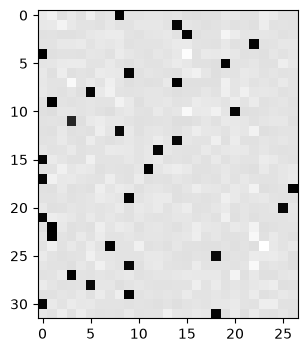

In [50]:
plt.figure(figsize=(4, 4))
plt.imshow(dlogits.detach().cpu(), cmap='gray')

## exercise 3: backpropagate BatchNorm in one step

Treat BatchNorm as one mathematical expression and simplify its derivative.

In [51]:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, device='cuda:0', grad_fn=<MaxBackward1>)


In [52]:
dhprebn.shape, bngain.shape, bnvar_inv.shape, dbnraw.shape, dbnraw.sum(0).shape

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([64]))

In [53]:
dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
cmp('hprebn', dhprebn, hprebn)

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


## exercise 4: put the full backward pass together

First keep autograd for a few steps so every manual parameter gradient can be checked.

In [54]:
# init
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g).to(device)
W1 = (torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)).to(device)
b1 = (torch.randn(n_hidden,                        generator=g) * 0.1).to(device)
W2 = (torch.randn((n_hidden, vocab_size),          generator=g) * 0.1).to(device)
b2 = (torch.randn(vocab_size,                      generator=g) * 0.1).to(device)
bngain = (torch.randn((1, n_hidden))*0.1 + 1.0).to(device)
bnbias = (torch.randn((1, n_hidden))*0.1).to(device)

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

max_steps = 200000
batch_size = 32
n = batch_size
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
  Xb, Yb = Xtr[ix], Ytr[ix]

  # forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1)
  hprebn = embcat @ W1 + b1
  bnmean = hprebn.mean(0, keepdim=True)
  bnvar = hprebn.var(0, keepdim=True, unbiased=True)
  bnvar_inv = (bnvar + 1e-5)**-0.5
  bnraw = (hprebn - bnmean) * bnvar_inv
  hpreact = bngain * bnraw + bnbias
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)

  # PyTorch backward pass for checking
  for p in parameters:
    p.grad = None
  loss.backward()

  # manual backward pass
  dlogits = F.softmax(logits, 1)
  dlogits[range(n), Yb] -= 1
  dlogits /= n
  dh = dlogits @ W2.T
  dW2 = h.T @ dlogits
  db2 = dlogits.sum(0)
  dhpreact = (1.0 - h**2) * dh
  dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
  dbnbias = dhpreact.sum(0, keepdim=True)
  dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
  dembcat = dhprebn @ W1.T
  dW1 = embcat.T @ dhprebn
  db1 = dhprebn.sum(0)
  demb = dembcat.view(emb.shape)
  dC = torch.zeros_like(C)
  for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
      ix = Xb[k,j]
      dC[ix] += demb[k,j]
  grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]

  # update with the PyTorch gradients while checking
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i >= 100:
    break

for p, grad in zip(parameters, grads):
  cmp(str(tuple(p.shape)), grad, p)

12297


(27, 10)        | exact: False | approximate: True  | maxdiff: 2.0489096641540527e-08
(30, 200)       | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
(200,)          | exact: False | approximate: True  | maxdiff: 4.423782229423523e-09
(200, 27)       | exact: False | approximate: True  | maxdiff: 1.1175870895385742e-08
(27,)           | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09
(1, 200)        | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09
(1, 200)        | exact: False | approximate: True  | maxdiff: 4.423782229423523e-09


In [55]:
# Reinitialize and train using only the manual backward pass.
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g).to(device)
W1 = (torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)).to(device)
b1 = (torch.randn(n_hidden,                        generator=g) * 0.1).to(device)
W2 = (torch.randn((n_hidden, vocab_size),          generator=g) * 0.1).to(device)
b2 = (torch.randn(vocab_size,                      generator=g) * 0.1).to(device)
bngain = (torch.randn((1, n_hidden))*0.1 + 1.0).to(device)
bnbias = (torch.randn((1, n_hidden))*0.1).to(device)

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

max_steps = 200000
batch_size = 32
n = batch_size
lossi = []

with torch.no_grad():
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hprebn = embcat @ W1 + b1
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # manual backward pass
    dlogits = F.softmax(logits, 1)
    dlogits[range(n), Yb] -= 1
    dlogits /= n
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    dhpreact = (1.0 - h**2) * dh
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    dC.index_add_(0, Xb.view(-1), demb.view(-1, n_embd)) # the same accumulation, efficiently on the GPU
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p, grad in zip(parameters, grads):
      p.data += -lr * grad

    if i % 10000 == 0:
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

12297
      0/ 200000: 3.8056


  10000/ 200000: 2.2416


  20000/ 200000: 2.1598


  30000/ 200000: 2.3599


  40000/ 200000: 1.9323


...

 150000/ 200000: 1.7285


 160000/ 200000: 2.2778


 170000/ 200000: 1.9262


 180000/ 200000: 2.2557


 190000/ 200000: 2.2155


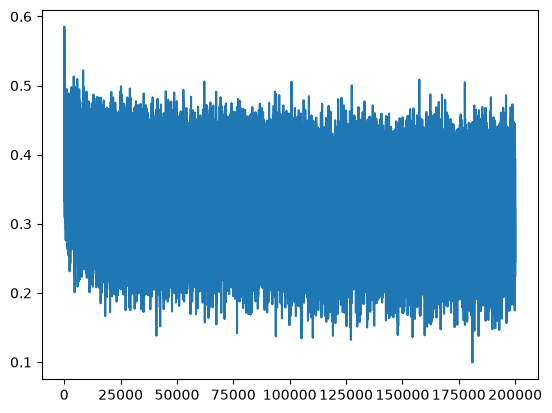

In [56]:
plt.plot(lossi)

In [57]:
# calibrate BatchNorm at the end of training
with torch.no_grad():
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [58]:
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.071040391921997
val 2.1074860095977783


In [59]:
# Karpathy achieved train 2.0719 and val 2.1162.

In [60]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

  out = []
  context = [0] * block_size
  while True:
    emb = C[torch.tensor([context], device=device)]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1).cpu()
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

carlah.
amille.
khi.
mri.
reh.
casparshi.
jazhitnalee.
art.
kaeli.
ner.
kia.
chaiir.
kaleigh.
ham.
join.
quinn.
sulin.
alvin.
quinathoniearynn.
jaxenni.
